# Atmospheric neutrinos from a *measured* atmosphere

### NASA AIRS satellite temperatures → MCEq → the neutrino rate at IceCube

A pion (or kaon) born in a cosmic-ray shower has two futures: **decay** into a neutrino,
or **hit an air nucleus** first and make no neutrino at all. Which one wins is
decided by the density of the air around it — **warm air is thin, so more pions
decay and more neutrinos arrive; cold dense air means fewer.** A neutrino
telescope therefore cares what the weather is doing, and this
notebook calculates it with real satellite data.

## What you need to install

```bash
pip install MCEq requests xarray "numpy>=2" netcdf4 matplotlib cartopy
pip install 'git+https://github.com/afedynitch/nrlmsis2.1'
```

You also need a free [Earthdata Login](https://urs.earthdata.nasa.gov), with
*NASA GESDISC DATA ARCHIVE* approved under Applications → Authorized Apps.

In [1]:
import datetime
import gzip
import hashlib
import time
import netrc
import os
import urllib.parse

import matplotlib.pyplot as plt
import numpy as np
import requests
import xarray as xr

### Settings — everything you might want to change lives here

In [2]:
G0 = 9.80665 # gravity constant
R_D = 287.06 # gas constant of dry air

# One month of austral winter. Select to your liking.
START_DATE, END_DATE = "2013-08-01", "2013-08-31"

# This is the "Earth patch" we want to download data for.
# We take 360deg in longitude and cut in latitude.
LAT_RANGE = (-90.0, -35.0)

# The satellite passes overhead twice a day.
# A = Ascending
# D = Descending
# Explaination comes later
OVERPASSES = ("A", "D")

# Storage
CACHE_DIR = "airs_cache" # store AIRS downloads here
OUTPUT_DIR = "airs_tables" # store output table for MCEq here
SURFACE_TABLE = os.path.join(OUTPUT_DIR, "airs_surface.csv") # he we are going to store the Earth elevations

# IceCube
SITE_LON, SITE_LAT = 0.0, -90.0 # Location
SITE_ELEVATION_M = 2835.0 # Surface elevation
SITE_DEPTH_M = 1948.0 # Depth of detector
# Neutrino energy threshold. We have no effective area, so the "rate" is the
# flux integrated above this value. 500 GeV puts the median of what is
# counted near 700 GeV, close to the ~900 GeV median of IceCube's up-going
# sample in https://arxiv.org/pdf/2303.04682.  Lower it and the rate stops
# caring about the atmosphere: at 100 GeV most parent mesons decay anyway.
E_THRESHOLD = 500.0
ZENITH_BAND = np.linspace(90.0, 115.0, 11)  # the up-going band, same band as https://arxiv.org/pdf/2303.04682
# IceCube sees every azimuth at once.  The month below solves every direction
# of the band on its own -- one MCEq solve per (zenith, azimuth) -- and
# integrates the rates over all of them.  AZIMUTH_STRIDE sets how many
# azimuths: 15 deg is 24 directions round the ring, and the band integral
# changes by less than 0.01% between 12 and 72 of them.
AZIMUTH_STRIDE = 15.0
AZIMUTHS = np.arange(0.0, 360.0, AZIMUTH_STRIDE)
# One direction for the illustrations that trace a single line of sight
# (0 = north, 90 = east; at the pole any value is a meridian).
AZIMUTH_DEG = 0.0
# Days solved in one batched call.  The directions near the horizon need
# ~950 integration steps each, and one day alone leaves the batched solver
# half idle while it waits for them.
DAYS_PER_CALL = 2

# Make this notebook FAST
# Use only every 3rd latitude and every 15th longitude of the data.
LAT_STRIDE, LON_STRIDE = 3, 15
# The rate counts neutrinos above E_THRESHOLD.  A cascade never moves energy
# upward, and primaries above 1e8 GeV add nothing measurable at 500 GeV, so the
# default 0.1 GeV..1e11 GeV energy grid is cut to 10 GeV..1e8 GeV: half the
# matrix, 2.3x faster, and the rate changes by 0.001%.  The grid is fixed when
# MCEqRun is constructed, so this has to come first.
import MCEq.config as config
config.e_min, config.e_max = 10.0, 1e8


## 1. The whole MCEq recipe, in 8 lines

MCEq solves the **coupled cascade equations**: it predicts the statistical average flux 
of a cosmic-ray air showers and tracks how many particles of each species and energy
are produced.

To run **these 8 lines** we need to **convert the AIRS data to .csv format**:

```python
import crflux.models as pm
import MCEq.geometry.density_profiles as dp
from MCEq.core import MCEqRun

# Load an AIRS (or other satellite) table
table = dp.AtmosphereTable.load_from_csv("my_atmosphere.csv.gz")

# Construct the Atmosphere with it
atm = dp.TabulatedAtmosphere(table, coord=(SITE_LON, SITE_LAT),   # lon, lat
                             surface_elevation_m=SITE_ELEVATION_M)     # where the ground is

# Build an MCEq instance
mceq = MCEqRun(interaction_model="SIBYLL2.3d",
               primary_model=(pm.HillasGaisser2012, "H3a"),
               theta_deg=0.0, density_model=atm)
               
# Solve the Cascade Equations
mceq.solve()
flux = mceq.get_solution("total_numu")   # Flux, per cm^2 s sr GeV
```

The CSV is a plain text table of height, temperature and pressure — it can
come from **any** source. Here it comes from a satellite.

### The route from satellite data to a neutrino flux

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


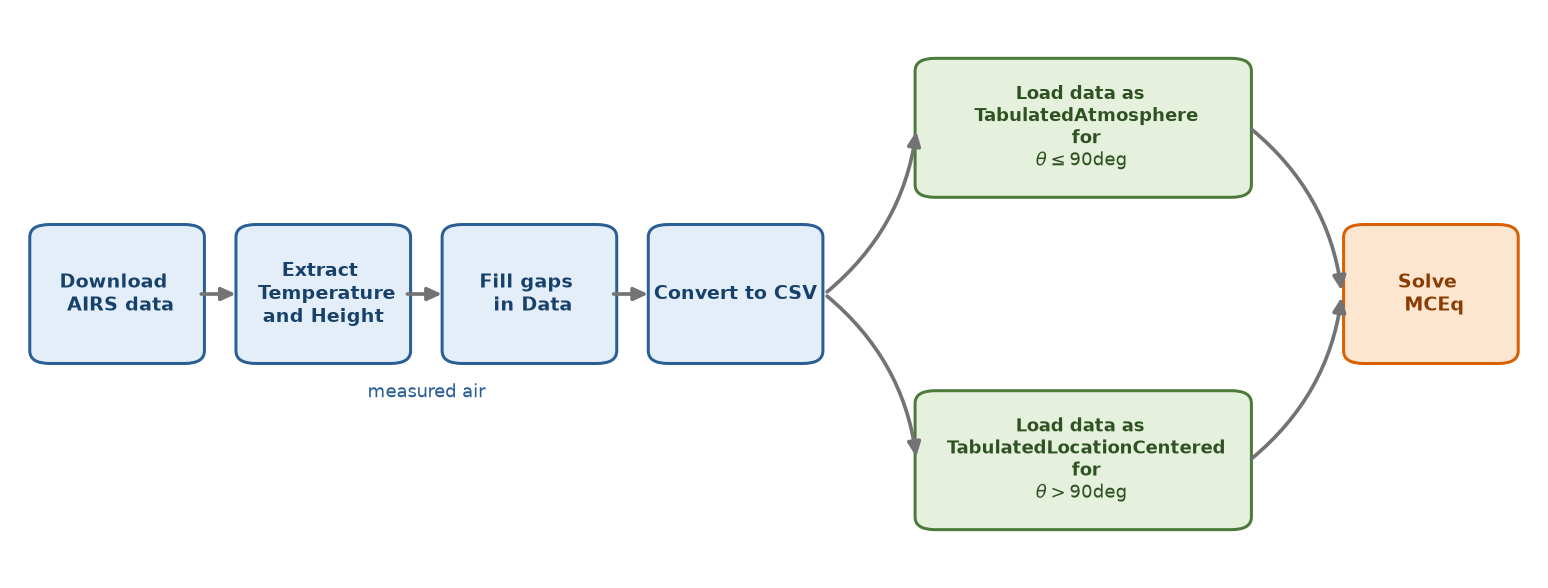

In [3]:
from matplotlib.patches import FancyBboxPatch

# Four steps to the table, then a fork: the direction you look decides which
# class reads it.  Every label is in words the reader already has.
chain = ["Download \n AIRS data", "Extract \n Temperature\nand Height",
         "Fill gaps \n in Data", "Convert to CSV"]
fork = [("Load data as \n TabulatedAtmosphere\n for\n" + r"$\theta \leq 90\deg$"),
        ("Load data as \n TabulatedLocationCentered\n for\n" + r"$\theta > 90\deg$")]

BW, GAP, BH = 0.20, 0.055, 0.26
fig, ax = plt.subplots(figsize=(13, 5.0), dpi=120)


def box(x, y, w, h, title, fc, ec, tc, ts=11.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.008,rounding_size=0.025",
                                fc=fc, ec=ec, lw=1.8))
    ax.text(x + w / 2, y + h * 0.50, title, ha="center", va="center",
            fontsize=ts, color=tc, weight="semibold")


def arrow(x0, y0, x1, y1, rad=0.0):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>,head_width=0.32,head_length=0.7",
                                color="0.45", lw=2.2,
                                connectionstyle=f"arc3,rad={rad}"))


MID = 0.50
for k, title in enumerate(chain):
    x = k * (BW + GAP)
    box(x, MID - BH / 2, BW, BH, title, "#e3eef8", "#2a5f95", "#17416b")
    if k:
        arrow(x - GAP, MID, x - 0.004, MID)
CHAIN_END = 3 * (BW + GAP) + BW

FX, FW = CHAIN_END + 0.13, 0.40
for k, title in enumerate(fork):
    y = MID + 0.20 if k == 0 else MID - 0.20 - BH
    box(FX, y, FW, BH, title, "#e6f1dd", "#4b7a3a", "#2f5223", ts=11)
    arrow(CHAIN_END + 0.01, MID, FX - 0.006, y + BH / 2, rad=0.20 if k == 0 else -0.20)
    arrow(FX + FW + 0.006, y + BH / 2, FX + FW + 0.12, MID, rad=0.20 if k == 1 else -0.20)

MX = FX + FW + 0.13
box(MX, MID - BH / 2, BW, BH, "Solve \n MCEq", "#fce6d0", "#d95f02", "#8a3d02")

# Captions go under their own column, centred, so nothing lands on a box.
ax.text(CHAIN_END / 2, MID - BH / 2 - 0.075, "measured air", fontsize=10.5,
        color="#2a5f95", ha="center")
# ax.text(MX + BW / 2, MID - BH / 2 - 0.075, "what the detector sees", fontsize=10.5,
#         color="#d95f02", ha="center")
ax.set_xlim(-0.03, MX + BW + 0.03)
ax.set_ylim(MID - 0.20 - BH - 0.10, MID + 0.20 + BH + 0.10)
ax.axis("off")
fig.tight_layout()

## 2. What AIRS is

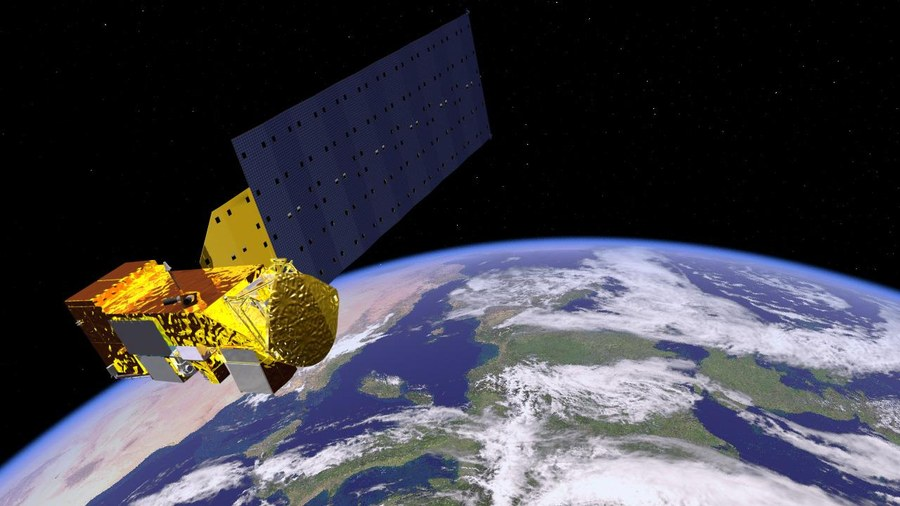

<sub>Artist's concept of NASA's **Aqua** spacecraft, which has carried AIRS since
2002. Image credit: NASA/JPL-Caltech
([PIA18156](https://www.jpl.nasa.gov/images/pia18156-aqua-satellite-orbiting-earth-artists-concept/)).</sub>

* **AIRS** — the Atmospheric Infrared Sounder — measures Earth's own infrared
  spectrum, and a infers the **temperature profile**.
* We use the daily gridded product `AIRS3STD` v7.0: temperature and
  geopotential height on **24 pressure levels** (1000 → 1 hPa), on a 1°×1° grid.
* $T$ and $p$ give density through the ideal gas law; geopotential height says
  at what **altitude** to put it. That is everything MCEq needs.

### The catch

Aqua's orbit is inclined 98.2°, so its ground track turns around at 81.8° and
**never crosses the pole**. Right where IceCube sits, AIRS looks least often.

Aqua crosses the equator twice a day, northbound ~13:30 and southbound ~01:30
local time. The product keeps the two passes as separate grids, **A** and **D**.

## 3. Getting the data

Again: You **need a free [Earthdata Login](https://urs.earthdata.nasa.gov)**, with
*NASA GESDISC DATA ARCHIVE* approved under Applications → Authorized Apps.

You **need to generate a token**.


Credentials are read from `$EARTHDATA_TOKEN`, then `~/.edl_token`. Place your token in either.

___Dangerous Fallback___:
Place your username and password in `~/.netrc` as "urs.earthdata.nasa.gov < username > < password >".

It is **highly recommend** to **not place your plain passwords anywhere**. Use the token option.


### These are just helpers for downlaoding

In [4]:
# Plumbing: log in, ask NASA's catalogue for file names, GET one cached
# subset.  Nothing here is about atmospheres -- skip to the next cell.
CMR = "https://cmr.earthdata.nasa.gov/search/granules.json"
OPENDAP = "https://acdisc.gesdisc.eosdis.nasa.gov/opendap/Aqua_AIRS_Level3/AIRS3STD.7.0"


class EarthdataSession(requests.Session):
    """Keeps the Authorization header across the Earthdata Login redirect."""

    def rebuild_auth(self, request, response):
        # requests drops the header when a redirect changes host.  Right
        # everywhere else, wrong here, because the login lives on another host.
        if "Authorization" in request.headers:
            hosts = {urllib.parse.urlparse(u).hostname
                     for u in (response.request.url, request.url)}
            if len(hosts) > 1 and "urs.earthdata.nasa.gov" not in hosts:
                del request.headers["Authorization"]


def login():
    """A session authenticated by bearer token, or by ~/.netrc."""
    session = EarthdataSession()
    token = os.environ.get("EARTHDATA_TOKEN", "").strip()
    if not token and os.path.exists(os.path.expanduser("~/.edl_token")):
        token = open(os.path.expanduser("~/.edl_token")).read().strip()
    if token:
        session.headers["Authorization"] = f"Bearer {token}"
        return session
    try:
        user, _, password = netrc.netrc().authenticators("urs.earthdata.nasa.gov")
    except (FileNotFoundError, TypeError):
        raise RuntimeError(
            "No Earthdata credentials: set $EARTHDATA_TOKEN, write ~/.edl_token, "
            "or add urs.earthdata.nasa.gov to ~/.netrc."
        )
    session.auth = (user, password)
    return session


def find_granules(start, end):
    """{date: OPeNDAP url} for the AIRS3STD granules covering the dates."""
    reply = requests.get(CMR, timeout=60, params={
        "short_name": "AIRS3STD", "version": "7.0", "page_size": 200,
        "temporal": f"{start}T00:00:00Z,{end}T23:59:59Z"}).json()
    out = {}
    for entry in reply["feed"]["entry"]:
        name = entry["title"].split(":")[-1]      # ...AIRS.2013.08.05.L3....hdf
        year, month, day = name.split(".")[1:4]
        date = f"{year}-{month}-{day}"
        if start <= date <= end:
            out[date] = f"{OPENDAP}/{year}/{name}"
    return dict(sorted(out.items()))


def fetch(session, url, constraint, attempts=3):
    """Download one server-side subset, cached on the constraint's hash.

    The server cuts the subset out of the full granule before sending it, which
    can take minutes, and now and then it does not answer at all.  A month of
    days is 31 chances for that to happen, so a timed-out request is retried.
    """
    os.makedirs(CACHE_DIR, exist_ok=True)
    tag = hashlib.sha1(constraint.encode()).hexdigest()[:8]
    path = os.path.join(CACHE_DIR, url.rsplit("/", 1)[-1].replace(".hdf", f".{tag}.nc4"))
    if os.path.exists(path):
        return path
    for attempt in range(1, attempts + 1):
        try:
            reply = session.get(f"{url}.nc4?{urllib.parse.quote(constraint, safe='[]:,.')}",
                                timeout=900)
            reply.raise_for_status()
            break
        except (requests.ConnectionError, requests.Timeout) as error:
            if attempt == attempts:
                raise
            print(f"  {url.rsplit('/', 1)[-1][:15]}: {type(error).__name__}, retrying")
    with open(path + ".part", "wb") as out:      # never leave a half file
        out.write(reply.content)
    os.replace(path + ".part", path)
    return path

### This is the data access!

In [5]:
# Start a session
session = login()

# Find the data file given our Dates
granules = find_granules(START_DATE, END_DATE)

# Access the first file to get longitude, latitude,
# and the pressure levels
axes_path = fetch(session, next(iter(granules.values())),
                  "Latitude,Longitude,StdPressureLev")
with xr.open_dataset(axes_path) as axes:
    native_lat = axes["Latitude"].values.astype(float)
    n_lon = axes["Longitude"].size
    p_hpa_native = axes["StdPressureLev"].values.astype(float)

# Generate the mask according to the patch we want
rows = np.flatnonzero((native_lat >= LAT_RANGE[0]) & (native_lat <= LAT_RANGE[1]))
# start and end row for out lat range
J0, J1 = int(rows.min()), int(rows.max()) 

# Here we generate the "Request/Constraint String" for the data we want:
# Temperature and height for both passes, the
# terrain (elevation), and how many times AIRS measured each cell.
FIELDS = [f"{name}_{pas}" for pas in OVERPASSES for name in ("Temperature", "GPHeight")]
SURFACE = ["Topography", "TotalCounts_A", "TotalCounts_D"]
constraint = ",".join(
    [f"{n}[0:{p_hpa_native.size - 1}][{J0}:{J1}][0:{n_lon - 1}]" for n in FIELDS]
    + [f"{n}[{J0}:{J1}][0:{n_lon - 1}]" for n in SURFACE]
    + [f"Latitude[{J0}:{J1}]", f"Longitude[0:{n_lon - 1}]",
       f"StdPressureLev[0:{p_hpa_native.size - 1}]"])

print("This is how the generate constraint string looks like:\n", constraint)

paths = {date: fetch(session, url, constraint) for date, url in granules.items()}
total = sum(os.path.getsize(p) for p in paths.values())
print("We end up with: ", f"{len(paths)} granules, {total / 1e6:.0f} MB ")

This is how the generate constraint string looks like:
 Temperature_A[0:23][125:179][0:359],GPHeight_A[0:23][125:179][0:359],Temperature_D[0:23][125:179][0:359],GPHeight_D[0:23][125:179][0:359],Topography[125:179][0:359],TotalCounts_A[125:179][0:359],TotalCounts_D[125:179][0:359],Latitude[125:179],Longitude[0:359],StdPressureLev[0:23]
We end up with:  31 granules, 91 MB 


**Let's open one of the granules we downloaded!**

In [6]:
xr.open_dataset(paths[START_DATE])

<xarray.Dataset> Size: 8MB
Dimensions:         (Latitude: 55, Longitude: 360, StdPressureLev: 24)
Coordinates:
  * Latitude        (Latitude) float64 440B -35.0 -36.0 -37.0 ... -88.0 -89.0
  * Longitude       (Longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * StdPressureLev  (StdPressureLev) float32 96B 1e+03 925.0 850.0 ... 1.5 1.0
Data variables:
    TotalCounts_A   (Latitude, Longitude) float32 79kB ...
    Temperature_A   (StdPressureLev, Latitude, Longitude) float32 2MB ...
    GPHeight_A      (StdPressureLev, Latitude, Longitude) float32 2MB ...
    TotalCounts_D   (Latitude, Longitude) float32 79kB ...
    Temperature_D   (StdPressureLev, Latitude, Longitude) float32 2MB ...
    GPHeight_D      (StdPressureLev, Latitude, Longitude) float32 2MB ...
    Topography      (Latitude, Longitude) float32 79kB ...
Attributes: (12/420)
    HDFEOSVersion:                                        HDFEOS_V2.18
    identifier_product_doi:                               10.5067/UO3Q64CTTS1U
    identifier_product_doi_authority:                     http://dx.doi.org/
    history:                                              2026-09-21 07:01:46...
    history_json:                                         [{"$schema":"https:...
    ascending._FV_TotalCounts_A:                          -9999.0
    ...                                                   ...
    location.H2OPressureLev:                              1000.0
    location.H2OPressureLay:                              961.7692
    location.EmisFreqIR:                                  832.0
    location.EmisFreqMW:                                  23.8
    location.CoarseCloudLayer:                            865.0
    location.FineCloudLayer:                              1018.0

Next we write a helper to access a single day of data:

In [7]:
def load_day(path):
    """One granule on ascending-latitude, [0,360) longitude axes."""
    with xr.open_dataset(path) as ds:
        lat = ds["Latitude"].values.astype(float)
        lon = ds["Longitude"].values.astype(float) % 360.0
        fields = {n: np.moveaxis(ds[n].values.astype(float), 0, -1)
                  for n in FIELDS}
        fields.update({n: ds[n].values.astype(float) for n in SURFACE})
    order_lat, order_lon = np.argsort(lat), np.argsort(lon)
    for name, value in fields.items():
        value = value[np.ix_(order_lat, order_lon)]
        # -9999 is AIRS's fill value and not every field declares it.
        fields[name] = np.where(value <= -9998.0, np.nan, value)
    return lat[order_lat], lon[order_lon], fields


# Levels ascending in height, i.e. descending in pressure.
level_order = np.argsort(p_hpa_native)[::-1]
p_hpa = p_hpa_native[level_order]

lat, lon, first = load_day(paths[START_DATE])
elevation_m = np.nan_to_num(first["Topography"], nan=0.0)

print(f"{lat.size} x {lon.size} columns, {p_hpa.size} levels "
      f"({p_hpa[0]:g} to {p_hpa[-1]:g} hPa)")
print(f"elevation {elevation_m.min():.0f} to {elevation_m.max():.0f} m")

55 x 360 columns, 24 levels (1000 to 1 hPa)
elevation 0 to 4033 m


### Where AIRS actually looked

Every cell of the AIRS grid, coloured by **how many times AIRS measured it that
day**. Red means it was never measured at all on this pass.

Aqua's ground track stops at 81.8 deg, but its scan reaches sideways past that,
so the cap is thinly covered rather than empty.

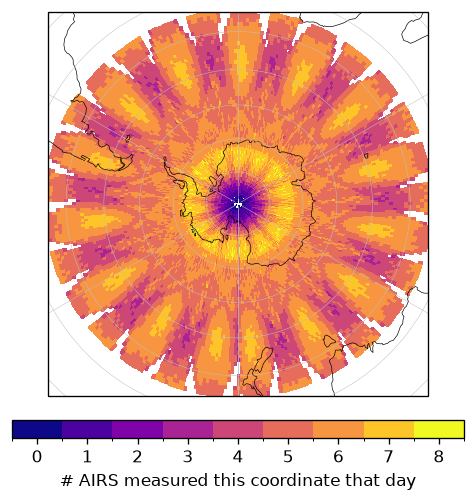

In [8]:
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm

polar = ccrs.SouthPolarStereo()


def polar_map(ax, field, lat, lon, cmap, label, quant_cmap=True):
    """A lon/lat field on a south polar stereographic map."""
    lon_closed = np.append(lon, lon[0] + 360.0)     # close the 0/360 seam
    field_closed = np.concatenate([field, field[:, :1]], axis=1)

    if quant_cmap:
        vmin = int(np.nanmin(field_closed))
        vmax = int(np.nanmax(field_closed))
        n_colors = vmax - vmin + 1
        base_cmap = plt.get_cmap(cmap, n_colors)
        bounds = np.arange(vmin - 0.5, vmax + 1.5, 1)
        norm = BoundaryNorm(bounds, base_cmap.N)
        ticks = np.arange(vmin, vmax + 1)
    else:
        base_cmap = cmap
        norm = None
        ticks = None
    
    mesh = ax.pcolormesh(lon_closed, lat, field_closed, cmap=base_cmap, norm=norm,
                         shading="auto", transform=ccrs.PlateCarree())
    ax.coastlines(lw=0.4)
    ax.gridlines(lw=0.3, color="0.75")
    ax.set_extent([-180, 180, *LAT_RANGE], ccrs.PlateCarree())
    plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.9,
                 aspect=25, label=label, ticks=ticks)
    return mesh


never_a = first["TotalCounts_A"] == 0
never_d = first["TotalCounts_D"] == 0

fig = plt.figure(figsize=(5.4, 5.2), dpi=120)
ax = fig.add_subplot(projection=polar)
total_passes = np.where(never_a, np.nan, first["TotalCounts_A"]) + np.where(never_d, np.nan, first["TotalCounts_D"])
polar_map(ax, total_passes, lat, lon,
          "plasma", "# AIRS measured this coordinate that day")

## 4. Missing levels

AIRS is a *measurement*, not a model: it reports a level only where the
retrieval worked. Two very different things look the same in the file.

* A level that **does not exist**, because the pressure at the surface never
  reaches it. A standard level is a pressure, not a height, so it is there
  only where the air above is heavy enough. Those levels are **left out** —
  `nan` — and the column simply has fewer than 24 of them. One tag covers
  this, but there are two reasons behind it:
  * **the ground is high.** Over the plateau the bottom three to five levels
    are inside rock and ice, and there is no air at those pressures anywhere
    in the column.
  * **the ground is at sea level, but the weather is low.** Surface pressure
    over the Southern Ocean is usually under 1000 hPa (the circumpolar
    trough), so the deepest AIRS level alone is missing. What it would have
    described is real air — a few hundred metres of it, right above the water
    — and the standard levels do not reach down to it.

  The map of *where the column stops*, below right, tells the two apart at a
  glance: 700 hPa and below over the continent, 925 hPa over the ocean.
* A **whole column** the pass never returned: cloud, or a gap between swaths.
  There is nothing to keep, so it is taken from somewhere else.

MCEq takes a gridded table whose columns stop at different depths: it aligns
them by pressure, keeps the short ones short, and continues each column from
its own lowest level down to the observation level. That last part is what
covers the real air in the sea-surface case; filling below the surface here
would only hide the surface from it.

What is *not* here: interpolation of a level missing in the middle of a column.
That case does not occur in this data — the rule used to be in this notebook
and fired on 0% of columns every day — so instead of code that is never
exercised there is an assertion below. MCEq refuses such a column anyway, since
a hole above the lowest level is missing data rather than terrain.

Two rules handle the rest, drawn below in order of **how much each one
invents**.

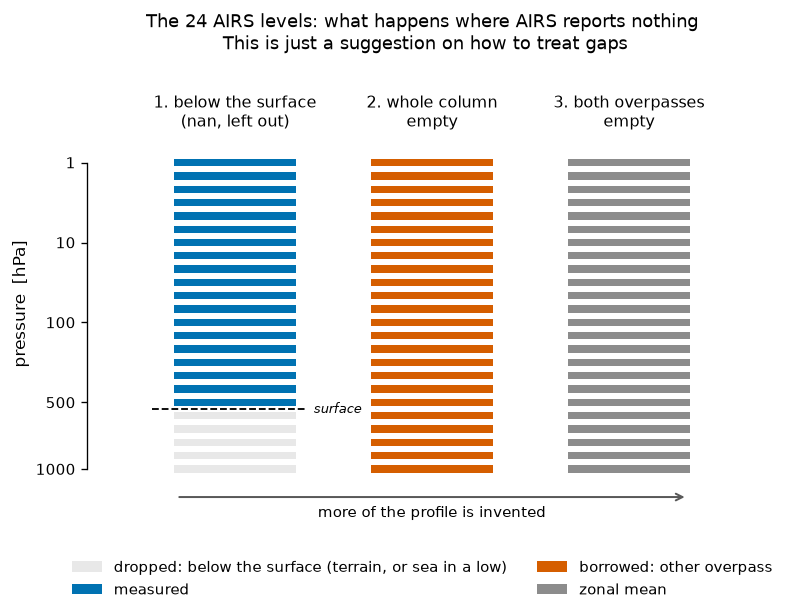

In [9]:
from matplotlib.patches import Patch

P = np.array([1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100,
              70, 50, 30, 20, 15, 10, 7, 5, 3, 2, 1.5, 1.0])   # 24 AIRS levels

# colour ramp: how much of the level is invented.  "dropped" invents nothing,
# which is why it comes first.
COLOR = {"d": "#e8e8e8", "m": "#0072B2", "b": "#D55E00", "z": "#8c8c8c"}
LABEL = {"d": "dropped: below the surface (terrain, or sea in a low)",
         "m": "measured", "b": "borrowed: other overpass", "z": "zonal mean"}

cols = [list("m" * 24), list("b" * 24), list("z" * 24)]
cols[0][0:5] = list("d" * 5)          # 1: no levels below the surface
titles = ["1. below the surface\n(nan, left out)", "2. whole column\nempty",
          "3. both overpasses\nempty"]

fig, ax = plt.subplots(figsize=(7.2, 4.5), dpi=120)
for k, col in enumerate(cols):
    for i, s in enumerate(col):
        ax.barh(i, 0.62, left=k - 0.31, height=0.55, color=COLOR[s])
    ax.text(k, 25.3, titles[k], ha="center", va="bottom", fontsize=9.5)

ax.plot([-0.42, 0.36], [4.5, 4.5], "k--", lw=1.1)
ax.text(0.40, 4.5, "surface", fontsize=8, style="italic", ha="left",
        va="center")
ax.annotate("", xy=(2.3, -2.1), xytext=(-0.3, -2.1),
            arrowprops=dict(arrowstyle="->", color="0.35", lw=1.2))
ax.text(1.0, -3.6, "more of the profile is invented", fontsize=9, ha="center")

ax.set_yticks([0, 5, 11, 17, 23], [f"{p:g}" for p in P[[0, 5, 11, 17, 23]]], fontsize=9)
ax.set_ylabel("pressure  [hPa]", fontsize=10)
ax.set_xticks([])
ax.set_xlim(-0.75, 2.65)
ax.set_ylim(-3.2, 28.0)
ax.spines["left"].set_bounds(0, 23)
for side in ("top", "right", "bottom"):
    ax.spines[side].set_visible(False)
ax.set_title("The 24 AIRS levels: what happens where AIRS reports nothing\n This is just a suggestion on how to treat gaps",
             fontsize=11, pad=28)
ax.legend(handles=[Patch(fc=COLOR[s], label=LABEL[s]) for s in "dmbz"],
          loc="lower center", bbox_to_anchor=(0.5, -0.24), ncol=2, frameon=False, fontsize=9)

**Next we implement the handling of missing levels:**

In [10]:
# just some tags to check what happened to which data later.  The order is the
# order they are drawn in: the column as AIRS delivered it first, then what was
# fetched from elsewhere.
MEASURED, BELOW_SURFACE, OTHER_OVERPASS, ZONAL_MEAN = 0, 1, 2, 3
SOURCE_NAMES = {MEASURED: "24 levels",
                BELOW_SURFACE: "< 24 levels;\nup to surface",
                OTHER_OVERPASS: "other pass",
                ZONAL_MEAN: "zonal mean"}


def fill_gaps(t_k, gph_m, other):
    """
    Leave the levels below the surface out, and fill the columns that are empty.

    A standard level exists only where the pressure reaches it, so a level
    below the local surface is absent from the file.  One tag, BELOW_SURFACE,
    covers that, but there are two reasons behind it, and they look nothing
    alike on a map of where the columns stop:

    * The ground is high.  On the plateau three to five levels are under rock
      and ice, and there is no air at those pressures at all.
    * The ground is at sea level but the weather is low.  Over the Southern
      Ocean the surface pressure is usually under 1000 hPa, so the deepest
      AIRS level alone is missing.  The air it would have described is real
      air, a few hundred metres of it above the water; the standard levels
      just do not reach down to it.  MCEq covers that stretch by extending the
      column from its lowest level to the observation level.

    Neither is filled: a short column stays short, and MCEq aligns the table's
    columns by pressure.  What *is* filled is a column the pass missed
    altogether, from the other overpass or from the latitude row.

    Input:
    t_k: Temperature at (lat, lon, pressure level)
    gph_m: Geopotential Height
    other: tuple (t_k, gph_m) for the other overpass, e.g. "D"

    Returns:
    (T, height, source) -- T and height are nan on the levels a column does
    not have, which are always the bottom ones.
    """
    n_lat, n_lon, n_lev = t_k.shape
    t, gph = t_k.copy(), gph_m.copy()
    good = np.isfinite(t) & np.isfinite(gph)
    source = np.full((n_lat, n_lon), MEASURED, np.int8) # logging in a map what we did to each coordinate

    # Rule 1 borrows a missing column from the other overpass.
    # The two passes are NOT averaged together: they are about twelve hours
    # apart, so combining them would smear the day/night difference we want to keep (for now).
    # You might want to average, or fill differently! Up to your taste.

    # missing data
    empty = ~good.any(axis=-1)
    # this finds the gapless data in the other pass
    usable = np.isfinite(other[0]) & np.isfinite(other[1])
    # fill where we can
    rescued = empty & usable.any(axis=-1)
    t[rescued], gph[rescued] = other[0][rescued], other[1][rescued]
    source[rescued] = OTHER_OVERPASS
    good = np.isfinite(t) & np.isfinite(gph)

    # Below the lowest level with data there is nothing to measure: that level
    # lies under the local surface, whether that is rock, ice or water.  So we
    # invent nothing and leave those levels at nan.
    lowest = good.argmax(axis=-1)
    source[good.any(axis=-1) & (lowest > 0)] = BELOW_SURFACE

    # Rule 2
    # We take the mean of the latitude row.
    # Again: You might want to spend more time in your own analysis in better interpolation.
    # A plain mean, not nanmean: the borrowed column then reaches only as deep
    # as every column of the row does, so it cannot end up with a level that
    # lies under its own terrain.
    empty = ~good.any(axis=-1)
    for j in np.flatnonzero(empty.any(axis=-1)):
        assert (~empty[j]).any(), (
            f"latitude row {j} is empty in both passes, so there is nothing to "
            "average; widen LAT_RANGE or pick another day")
        t[j, empty[j]] = t[j, ~empty[j]].mean(axis=0)
        gph[j, empty[j]] = gph[j, ~empty[j]].mean(axis=0)
        source[j, empty[j]] = ZONAL_MEAN

    # Every column must now run from its own lowest level all the way to the
    # top: MCEq needs the absent levels at the *bottom*, because a hole above
    # them is missing data rather than terrain, and it refuses such a table.
    # This is the check that replaces interpolating interior gaps -- they do
    # not occur in this month.  If they occur in yours, interpolate the hole in
    # log-p between the neighbouring levels, and tag it.
    filled = np.isfinite(t) & np.isfinite(gph)
    holed = filled.sum(axis=-1) + filled.argmax(axis=-1) != n_lev
    assert not holed.any(), (
        f"{holed.sum()} columns have a level missing above their lowest one; "
        "fill those holes (interpolate in log-p) and tag them")

    return t, gph, source

Let's test it for one day. The left map tags every column by what became of
it; the right one shows, wherever levels were dropped, the pressure
of the lowest one that survives. The values sit on the 24 AIRS levels, so
yellow means only the bottom level went — the ocean, where the surface
pressure fell below 1000 hPa — and dark means a deep stack of them is inside
the terrain.

terrain above sea level   32% of the grid, 3.08 levels dropped on average, lowest level kept 700 hPa (median)
at the sea surface        31% of the grid, 1.00 levels dropped on average, lowest level kept 925 hPa (median)


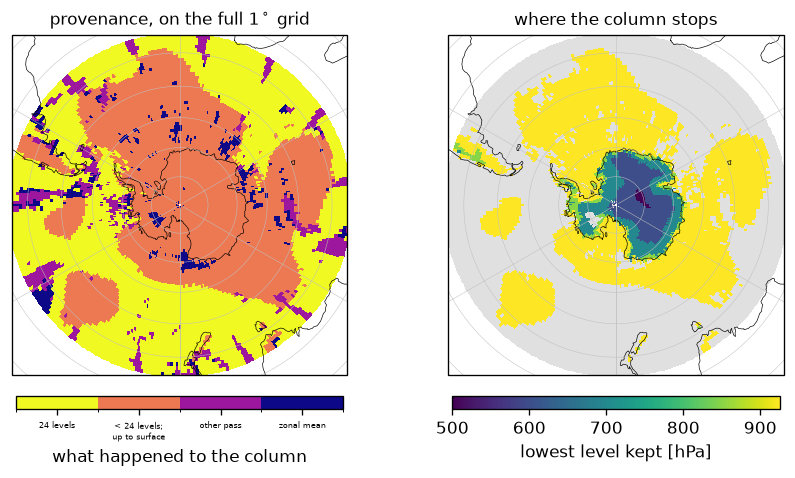

In [11]:
_, _, fields = load_day(paths[START_DATE])
raw = {p: (fields[f"Temperature_{p}"][..., level_order],
           fields[f"GPHeight_{p}"][..., level_order]) for p in OVERPASSES}
t_k, gph_m, source = fill_gaps(*raw['A'], raw['D'])

# The lowest level each column still has, where any were dropped.
cut = source == BELOW_SURFACE
kept = np.isfinite(t_k) & np.isfinite(gph_m)
p_bottom = np.where(cut, p_hpa[kept.argmax(axis=-1)], np.nan)

pressure_cmap = plt.get_cmap("viridis").copy()
pressure_cmap.set_bad("0.88")          # grey: the column is complete here

fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.6), dpi=120,
                         subplot_kw=dict(projection=polar))

mesh = polar_map(axes[0], source.astype(float), lat, lon,
                 "plasma_r", "what happened to the column")
mesh.colorbar.set_ticks(list(SOURCE_NAMES))
mesh.colorbar.set_ticklabels(list(SOURCE_NAMES.values()), fontsize=5)
axes[0].set_title("provenance, on the full 1$^\\circ$ grid", fontsize=10)

polar_map(axes[1], p_bottom, lat, lon, pressure_cmap,
          "lowest level kept [hPa]", quant_cmap=False)
axes[1].set_title("where the column stops", fontsize=10)

# One tag, two causes: the elevation says which, and they look nothing alike.
# AIRS's Topography is exactly zero over water, and the height of the surface
# is what decides whether a level exists -- not what the surface is made of, so
# the granule's LandSeaMask is the wrong field for this (flat land at sea level
# loses the 1000 hPa level exactly when the ocean does).
for label, where in (("terrain above sea level", cut & (elevation_m > 0.0)),
                     ("at the sea surface     ", cut & (elevation_m <= 0.0))):
    dropped = kept.argmax(axis=-1)[where]
    print(f"{label}  {where.mean():4.0%} of the grid, "
          f"{dropped.mean():.2f} levels dropped on average, "
          f"lowest level kept {np.median(p_hpa[dropped]):.0f} hPa (median)")

## 5. The table MCEq reads

A plain CSV. **Nothing in it is specific to AIRS** — this is the interface.

```
# MCEq tabulated atmosphere v1
lat_deg,lon_deg,h_cm,T_K,p_hPa
-89.0,0.0,283400.0,247.1,681.2
-89.0,0.0,510000.0,231.4,500.0
```

* `h_cm` — height above sea level.
* `T_K`, `p_hPa` — density follows from the ideal gas law.
* `lat_deg`, `lon_deg` — optional; they turn one column into a **grid** of
  them, one row per node and level.

A column may stop where its ground is: the levels it does not have are simply
not written (or written as `nan`, which is dropped on load). MCEq aligns such a
**ragged** grid by pressure — which is why `p_hPa` is needed — and requires the
missing levels to be at the bottom of the column, since a hole higher up is
missing data rather than terrain. `TabulatedAtmosphere` then carries each
column from its lowest level down to the observation level you give it.

One extra node is added at the pole, because AIRS's grid stops at −89° while
IceCube sits at −90°. At a pole every meridian meets, so its profile is the
mean of the −89° row over longitude.

In [12]:
def write_table(path, lat, lon, h_cm, t_k, p_hpa):
    """Write one gridded MCEq atmosphere table, one row per node and level.

    The levels below the surface are nan by now, and a nan row carries no
    information, so they are left out of the file altogether.  That makes the
    table ragged, which MCEq reads as long as it can align the columns by
    pressure.
    """
    n_lat, n_lon, n_lev = h_cm.shape
    rows = np.column_stack([
        np.repeat(lat, n_lon * n_lev), np.tile(np.repeat(lon, n_lev), n_lat),
        h_cm.reshape(-1), t_k.reshape(-1), np.tile(p_hpa, n_lat * n_lon)])
    rows = rows[np.isfinite(rows[:, 2]) & np.isfinite(rows[:, 3])]
    with gzip.open(path, "wt", compresslevel=1) as out:
        out.write("# MCEq tabulated atmosphere v1\nlat_deg,lon_deg,h_cm,T_K,p_hPa\n")
        np.savetxt(out, rows, delimiter=",", fmt="%.4f,%.4f,%.6e,%.3f,%.6g")


def add_pole(lat, h_cm, t_k):
    """Add a node at -90: the mean of the southernmost row over longitude.

    A plain mean, so the pole column reaches only as deep as every column of
    the -89 row does.  nanmean would take it below the surface of the shallowest
    of them.
    """
    shape = (1,) + h_cm.shape[1:]
    return (np.concatenate([[-90.0], lat]),
            np.concatenate([np.broadcast_to(h_cm[0].mean(axis=0), shape), h_cm]),
            np.concatenate([np.broadcast_to(t_k[0].mean(axis=0), shape), t_k]))


os.makedirs(OUTPUT_DIR, exist_ok=True)
np.savetxt(SURFACE_TABLE, np.column_stack([
    np.repeat(lat, lon.size), np.tile(lon, lat.size), elevation_m.reshape(-1)]),
    delimiter=",", fmt="%.4f,%.4f,%.2f",
    header="lat_deg,lon_deg,h_surface_m", comments="")

table_files, column_source, map_temperature = {}, {}, {}
MAP_LEVEL = int(np.argmin(np.abs(p_hpa - 100.0)))
for date, path in paths.items():
    _, _, fields = load_day(path)
    raw = {p: (fields[f"Temperature_{p}"][..., level_order],
               fields[f"GPHeight_{p}"][..., level_order]) for p in OVERPASSES}
    for pas in OVERPASSES:
        other = raw["D" if pas == "A" else "A"]
        t_k, gph_m, source = fill_gaps(*raw[pas], other)

     
        # The region and the filling rules are in the name, so a re-run with
        # different settings writes new files instead of reusing old ones.
        tag = hashlib.sha1(f"{LAT_RANGE}".encode()).hexdigest()[:6]
        out_path = os.path.join(OUTPUT_DIR, f"airs_{date}_{pas}_{tag}.csv.gz")
        if not os.path.exists(out_path):
            pole_lat, h_cm, pole_t = add_pole(lat, gph_m * 100.0, t_k)
            write_table(out_path, pole_lat, lon, h_cm, pole_t, p_hpa)
        table_files[(date, pas)] = out_path
        column_source[(date, pas)] = source
        map_temperature[(date, pas)] = t_k[..., MAP_LEVEL] # store test temperatur
    print(f"{date} A pass  " + "  ".join(
        f"{name.replace(chr(10), ' ')} {np.mean(column_source[(date, 'A')] == value):.0%}"
        for value, name in SOURCE_NAMES.items()))

2013-08-01 A pass  24 levels 29%  < 24 levels; up to surface 62%  other pass 4%  zonal mean 4%
2013-08-02 A pass  24 levels 30%  < 24 levels; up to surface 60%  other pass 4%  zonal mean 7%
2013-08-03 A pass  24 levels 28%  < 24 levels; up to surface 62%  other pass 4%  zonal mean 6%
2013-08-04 A pass  24 levels 26%  < 24 levels; up to surface 65%  other pass 5%  zonal mean 4%
2013-08-05 A pass  24 levels 28%  < 24 levels; up to surface 64%  other pass 4%  zonal mean 4%
2013-08-06 A pass  24 levels 28%  < 24 levels; up to surface 65%  other pass 4%  zonal mean 4%


2013-08-07 A pass  24 levels 33%  < 24 levels; up to surface 61%  other pass 3%  zonal mean 3%
2013-08-08 A pass  24 levels 30%  < 24 levels; up to surface 63%  other pass 4%  zonal mean 3%
2013-08-09 A pass  24 levels 29%  < 24 levels; up to surface 64%  other pass 4%  zonal mean 3%
2013-08-10 A pass  24 levels 27%  < 24 levels; up to surface 66%  other pass 4%  zonal mean 3%
2013-08-11 A pass  24 levels 28%  < 24 levels; up to surface 64%  other pass 4%  zonal mean 4%
2013-08-12 A pass  24 levels 32%  < 24 levels; up to surface 61%  other pass 3%  zonal mean 4%


2013-08-13 A pass  24 levels 33%  < 24 levels; up to surface 58%  other pass 5%  zonal mean 4%
2013-08-14 A pass  24 levels 34%  < 24 levels; up to surface 58%  other pass 4%  zonal mean 4%
2013-08-15 A pass  24 levels 35%  < 24 levels; up to surface 57%  other pass 5%  zonal mean 3%
2013-08-16 A pass  24 levels 34%  < 24 levels; up to surface 56%  other pass 5%  zonal mean 4%
2013-08-17 A pass  24 levels 32%  < 24 levels; up to surface 60%  other pass 4%  zonal mean 3%
2013-08-18 A pass  24 levels 33%  < 24 levels; up to surface 62%  other pass 3%  zonal mean 2%


2013-08-19 A pass  24 levels 34%  < 24 levels; up to surface 61%  other pass 3%  zonal mean 2%
2013-08-20 A pass  24 levels 32%  < 24 levels; up to surface 61%  other pass 5%  zonal mean 3%
2013-08-21 A pass  24 levels 33%  < 24 levels; up to surface 61%  other pass 4%  zonal mean 3%
2013-08-22 A pass  24 levels 34%  < 24 levels; up to surface 60%  other pass 4%  zonal mean 2%
2013-08-23 A pass  24 levels 29%  < 24 levels; up to surface 63%  other pass 5%  zonal mean 3%
2013-08-24 A pass  24 levels 28%  < 24 levels; up to surface 64%  other pass 4%  zonal mean 4%


2013-08-25 A pass  24 levels 28%  < 24 levels; up to surface 64%  other pass 4%  zonal mean 4%
2013-08-26 A pass  24 levels 29%  < 24 levels; up to surface 60%  other pass 3%  zonal mean 7%
2013-08-27 A pass  24 levels 29%  < 24 levels; up to surface 61%  other pass 4%  zonal mean 6%
2013-08-28 A pass  24 levels 30%  < 24 levels; up to surface 62%  other pass 4%  zonal mean 4%
2013-08-29 A pass  24 levels 30%  < 24 levels; up to surface 63%  other pass 4%  zonal mean 4%
2013-08-30 A pass  24 levels 30%  < 24 levels; up to surface 63%  other pass 3%  zonal mean 3%


2013-08-31 A pass  24 levels 32%  < 24 levels; up to surface 61%  other pass 3%  zonal mean 4%


## 6. Driving MCEq with the table

You built the CSV in Part 5. Handing it to MCEq is three lines:

```python
table = dp.AtmosphereTable.load_from_csv(table_files[(START_DATE, "A")])
atm = dp.TabulatedAtmosphere(table, coord=(lon, lat), surface_elevation_m=2835)
```

⚠️ A `TabulatedAtmosphere` uses **the same column for every direction**. That is
exact straight up, but at large zenith angles the shower drifts hundreds of
kilometres downrange — then you want `TabulatedLocationCentered`

Now we look at the measured AIRS column at the pole against **NRLMSISE-21**, the
climatology MCEq ships with.

AtmosphereTable(grid 56x360, 19..24 levels, lat -90.00..-35.00, lon 0.00..359.00)


vertical column depth: AIRS 688, NRLMSISE-00 689 g/cm^2 (-0.0%)


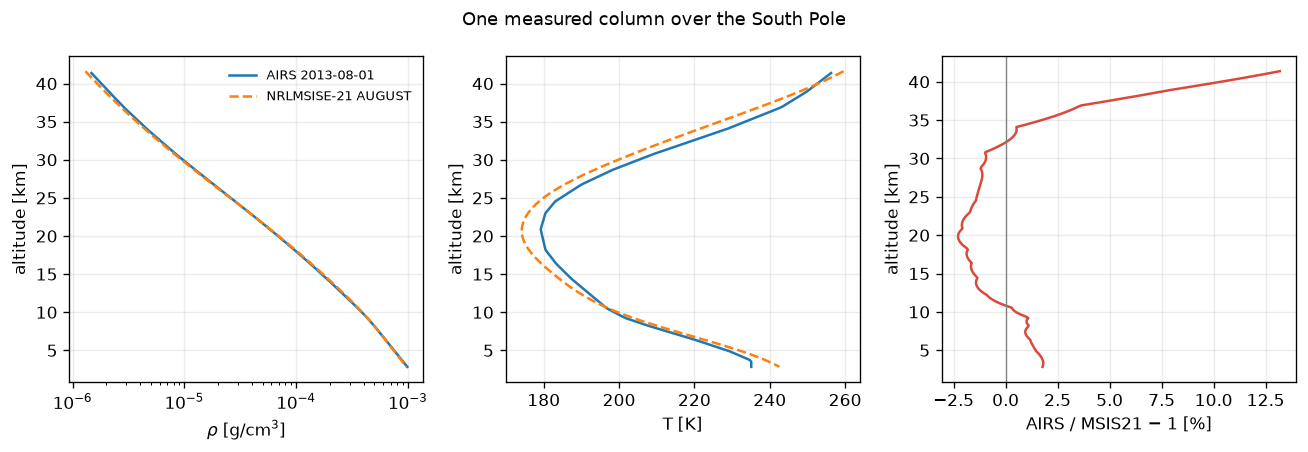

In [13]:
import MCEq.geometry.density_profiles as dp

first_key = (START_DATE, "A")
table = dp.AtmosphereTable.load_from_csv(table_files[first_key])
print(table)

airs_atm = dp.TabulatedAtmosphere(table, coord=(SITE_LON, SITE_LAT),
                                  surface_elevation_m=SITE_ELEVATION_M)
msis_atm = dp.MSIS21IceCubeCentered("SouthPole", "August")
for atm in (airs_atm, msis_atm):
    atm.set_theta(0.0)

print(f"vertical column depth: AIRS {airs_atm.max_X:.0f}, "
      f"NRLMSISE-00 {msis_atm.max_X:.0f} g/cm^2 "
      f"({100 * (airs_atm.max_X / msis_atm.max_X - 1):+.1f}%)")

# Read the profiles back through the interface MCEq integrates, not from file.
X = np.geomspace(1.0, min(airs_atm.max_X, msis_atm.max_X), 200)
height = {a: np.array([a.X2h(x) for x in X]) / 1e5 for a in (airs_atm, msis_atm)}
density = {a: np.array([a.X2rho(x) for x in X]) for a in (airs_atm, msis_atm)}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), dpi=120)
for atm, label, style in ((airs_atm, f"AIRS {START_DATE}", "-"),
                          (msis_atm, f"NRLMSISE-21 AUGUST", "--")):
    axes[0].plot(density[atm], height[atm], style, label=label)
    axes[1].plot([atm.get_temperature(h * 1e5) for h in height[atm]],
                 height[atm], style, label=label)
axes[2].plot(100 * (density[airs_atm] / density[msis_atm] - 1), height[airs_atm],
             color="#d94a3d")
axes[2].axvline(0, color="0.5", lw=0.8)

axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\rho$ [g/cm$^3$]")
axes[1].set_xlabel("T [K]")
axes[2].set_xlabel("AIRS / MSIS21 $-$ 1 [%]")
for ax in axes:
    ax.set_ylabel("altitude [km]")
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle("One measured column over the South Pole", fontsize=11)
fig.tight_layout()

## 7. From atmosphere to flux to rate

```python
mceq.solve()
mceq.get_solution("total_numu")                       # Flux per cm2 s sr GeV
mceq.n_particles("total_numu", min_energy_cutoff=500) # integrated, per cm2 s sr
```

* `get_solution` → a **differential flux**.
* `n_particles` → integrates it above a threshold. This notebook calls that the
  **rate** — but note it is still *per steradian*, and still not an event rate.
* `total_numu` is the neutrino only; `total_antinumu` is the antineutrino. A
  detector counts both, so everything below adds them.

**Many atmospheres at once.** Every grid and scan below goes through
`mceq.solve_batch(conditions=[...])`, which solves one condition per entry of
the list and returns them together. `solution.K` is how many came back, and
`solution.get_solution(name, k=k)` reads out entry `k` — in the same order as
the list you passed. It is a speed trick, not different physics: the result is
what a loop over `set_density_model` + `solve()` would give, and the cell below
checks one against the other.

In [14]:
import crflux.models as pm
import MCEq.config as config
from MCEq.core import MCEqRun

NU = ("total_numu", "total_antinumu")     # a detector counts both

mceq = MCEqRun(interaction_model="SIBYLL2.3E",
               primary_model=(pm.HillasGaisser2012, "H3a"),
               theta_deg=0.0, density_model=airs_atm)
e_grid, e_bins, e_widths = mceq.e_grid, mceq.e_bins, mceq.e_widths
edge = float(e_bins[e_bins >= E_THRESHOLD][0])


# e_bins are edges, e_widths and e_grid are the bins between them, so the same
# index selects the bin that starts at `edge`.
first_bin = int(np.searchsorted(e_bins, E_THRESHOLD))


def rate(spectra):
    """Flux integrated above E_THRESHOLD, per cm^2 s sr. Works on arrays."""
    return np.sum((np.asarray(spectra) * e_widths)[..., first_bin:], axis=-1)


# Two atmospheres, one batched call: this is how every grid below is solved.
solved = mceq.solve_batch(conditions=[{"zenith_deg": 0.0, "density_model": a}
                                      for a in (airs_atm, msis_atm)])
airs_flux, msis_flux = (sum(solved.get_solution(n, k=k) for n in NU)
                        for k in (0, 1))


print(f"\nrate above {edge:.0f} GeV: AIRS {rate(airs_flux):.3e}, "
      f"MSIS21 {rate(msis_flux):.3e} /cm^2/s/sr "
      f"({100 * (rate(airs_flux) / rate(msis_flux) - 1):+.2f}%)")

MCEqRun::set_interaction_model(): SIBYLL23E
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, np.int64(0))).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, np.int64(0))).


MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)



rate above 501 GeV: AIRS 4.475e-08, MSIS21 4.457e-08 /cm^2/s/sr (+0.40%)


## 8. The rate across Antarctica

One atmosphere per grid node, one solve per node, **all in a single
`solve_batch` call**.

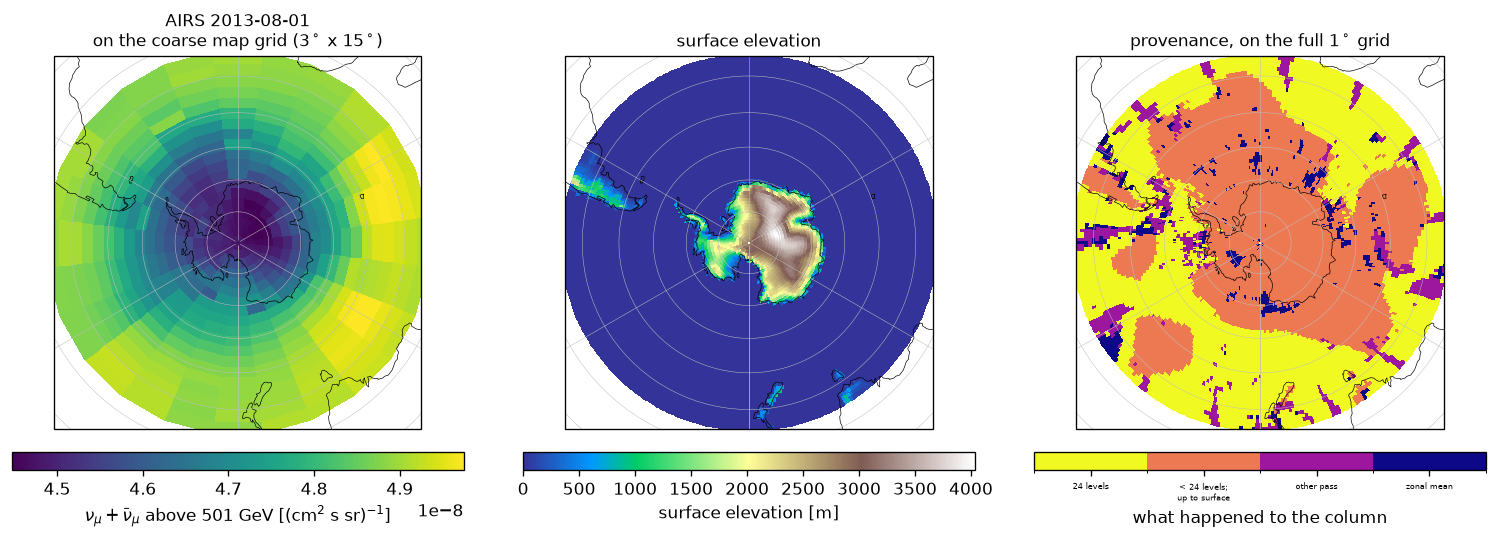

In [15]:
map_j = np.flatnonzero(lat)[::LAT_STRIDE]
map_i = np.arange(lon.size)[::LON_STRIDE]
map_lat, map_lon = lat[map_j], lon[map_i]


def rate_map(table):
    """Vertical numu+antinumu spectra at every map node, in one batched solve."""
    atmospheres = [
        dp.TabulatedAtmosphere(table, coord=(float(lon[i]), float(lat[j])),
                               surface_elevation_m=max(elevation_m[j, i], 0.0))
        for j in map_j for i in map_i]
    solution = mceq.solve_batch(
        conditions=[{"zenith_deg": 0.0, "density_model": a} for a in atmospheres])
    spectra = np.array([sum(solution.get_solution(n, k=k) for n in NU)
                        for k in range(solution.K)])
    return spectra.reshape(map_lat.size, map_lon.size, e_grid.size)


start = time.time()
spectra = rate_map(table)
today = rate(spectra)

fig = plt.figure(figsize=(13, 4.6), dpi=120)
ax = fig.add_subplot(1, 3, 1, projection=polar)
polar_map(ax, today, map_lat, map_lon, "viridis",
          rf"$\nu_\mu+\bar\nu_\mu$ above {edge:.0f} GeV [(cm$^2$ s sr)$^{{-1}}$]", quant_cmap=False)
ax.set_title(f"AIRS {START_DATE}\non the coarse map grid "
             f"({LAT_STRIDE}$^\\circ$ x {LON_STRIDE}$^\\circ$)", fontsize=10)

ax = fig.add_subplot(1, 3, 2, projection=polar)
polar_map(ax, elevation_m, lat, lon, "terrain", "surface elevation [m]", quant_cmap=False)
ax.set_title("surface elevation", fontsize=10)

ax = fig.add_subplot(1, 3, 3, projection=polar)
mesh = polar_map(ax, column_source[first_key].astype(float), lat, lon,
                 "plasma_r", "what happened to the column")
mesh.colorbar.set_ticks(list(SOURCE_NAMES))
mesh.colorbar.set_ticklabels(list(SOURCE_NAMES.values()), fontsize=5)
ax.set_title("provenance, on the full 1$^\\circ$ grid", fontsize=10)

for ax in fig.axes[::2]:
    ax.plot(SITE_LON, SITE_LAT, "k*", ms=12, transform=ccrs.PlateCarree())
fig.tight_layout()

In [16]:
# Load the rest of the month.  The animation that uses this is at the very
# end of the notebook, so the main line is not interrupted here.
month_dates = sorted({d for d, pas in table_files})
day_tables = {START_DATE: table}
month = [spectra]

start = time.time()
for k, date in enumerate(month_dates[1:], 1):
    day_tables[date] = dp.AtmosphereTable.load_from_csv(table_files[(date, "A")])
    month.append(rate_map(day_tables[date]))
    if k % 5 == 0 or k == len(month_dates) - 1:
        print(f"  {k + 1:2d} days  {time.time() - start:4.0f} s")
month = np.array(month)

month_rate = rate(month)
anomaly = 100 * (month_rate / month_rate.mean(axis=0) - 1)
swing = 100 * (month_rate.max(axis=0) / month_rate.min(axis=0) - 1)

# Is the motion weather, or the gap filling changing its mind between days?
# Compare the nodes AIRS measured on nearly every day with the rest.
measured_days = np.array([column_source[(d, "A")][np.ix_(map_j, map_i)] == MEASURED
                          for d in month_dates]).mean(axis=0)
mostly = measured_days >= 0.8
print(f"\nover the month: {np.median(swing):.2f}% peak to peak at the median node")
if mostly.any() and not mostly.all():
    print(f"  measured on 80% of the days or more ({mostly.mean():.0%} of nodes): "
          f"{np.median(swing[mostly]):.2f}%,  the rest: {np.median(swing[~mostly]):.2f}%")


   6 days    68 s


  11 days   138 s


  16 days   207 s


  21 days   274 s


  26 days   343 s


  31 days   409 s

over the month: 2.41% peak to peak at the median node
  measured on 80% of the days or more (11% of nodes): 1.86%,  the rest: 2.53%


## 9. What IceCube actually sees

IceCube's clean muon-neutrino sample comes **from below**.

**The catch is in the schematic below.** A neutrino arriving at 115° entered the
atmosphere about 50° of great circle away, over the Southern Ocean. That air is
nowhere near the detector, and tens of kelvin warmer. Tilting the pole's own column would
simply be wrong. `TabulatedLocationCentered` samples the table **where the
shower actually is**. IceCube sees every azimuth at once. Averaging the
atmosphere around that ring *before* solving -- which the class does when it is
given no azimuth -- is not what the detector does: it sums the neutrinos from
every direction, and a cascade is not linear in the air it develops in. So the
month below solves **every direction of the band on its own**, one MCEq solve
per (zenith, azimuth), and integrates the rates. The two illustrations that
follow first trace a single azimuth, `AZIMUTH_DEG`, because the geometry is
easier to see along one line.

The schematic also explains something that otherwise looks backwards: the column
depth **falls** as the detector zenith grows. Further below the horizon means the
shower stands closer to *its own* vertical, so it crosses less air, not more.

(None,
 (np.float64(-1.63), np.float64(-0.3), np.float64(-0.3), np.float64(1.25)))

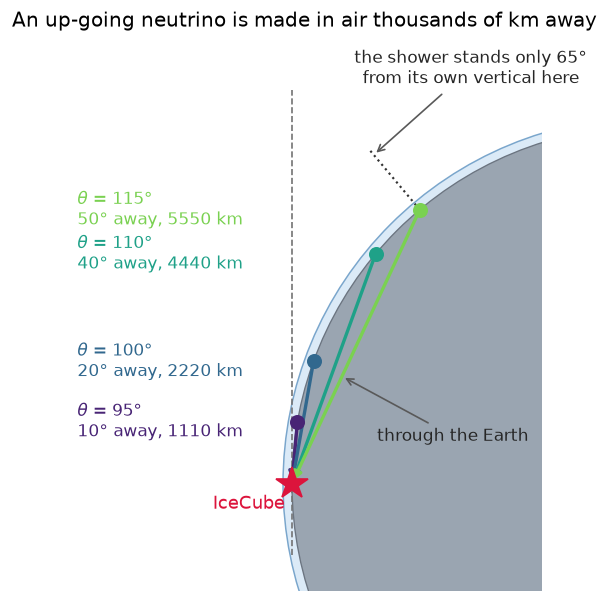

In [17]:
# Zoomed on the sector that matters.  The atmosphere shell is drawn thicker
# than it is; the entry points are placed on the surface, 2*theta - 180 degrees
# of great circle from the detector, which makes each drawn ray arrive at
# exactly its labelled zenith.
R, H = 1.0, 0.025
detector = np.array([-R, 0.0])

fig, ax = plt.subplots(figsize=(7.4, 6.0), dpi=120)
ax.add_patch(plt.Circle((0, 0), R + H, fc="#dbeaf7", ec="#7aa6cc", lw=0.9))
ax.add_patch(plt.Circle((0, 0), R, fc="#9aa5b1", ec="#6b7480", lw=0.8))
ax.plot([-R, -R], [-0.2, 1.1], "--", color="0.45", lw=1)

for theta, colour in zip([95, 100, 110, 115],
                         plt.cm.viridis(np.linspace(0.1, 0.8, 4))):
    away = 2 * theta - 180                      # degrees of great circle
    out = np.array([-np.cos(np.radians(away)), np.sin(np.radians(away))])
    ax.annotate("", xy=detector, xytext=R * out,
                arrowprops=dict(arrowstyle="-|>", color=colour, lw=2.0))
    ax.plot(*(R * out), "o", color=colour, ms=8, zorder=4)
    ax.text(-1.60, R * out[1], f"$\\theta$ = {theta}°\n{away}° away, "
            f"{away * 111:.0f} km", color=colour, fontsize=10, va="center")

# At the far end the shower stands much closer to its own vertical.
far = R * np.array([-np.cos(np.radians(50)), np.sin(np.radians(50))])
ax.plot(*np.c_[far, 1.22 * far], ":", color="0.2", lw=1.3)
ax.annotate("the shower stands only 65°\nfrom its own vertical here",
            xy=1.20 * far, xytext=(-0.50, 1.12), fontsize=10, color="0.15",
            ha="center", arrowprops=dict(arrowstyle="->", color="0.35"))
ax.annotate("through the Earth", xy=(-0.86, 0.30), xytext=(-0.55, 0.12),
            fontsize=10, color="0.15", ha="center",
            arrowprops=dict(arrowstyle="->", color="0.35"))

ax.plot(*detector, "*", color="crimson", ms=20, zorder=5)
ax.text(-R - 0.02, -0.07, "IceCube", ha="right", fontsize=11, color="crimson")
ax.set_title("An up-going neutrino is made in air thousands of km away",
             fontsize=12)
ax.set_xlim(-1.63, -0.30), ax.set_ylim(-0.30, 1.25)
ax.set_aspect("equal"), ax.axis("off")

### Sampling the table where the shower is

`TabulatedLocationCentered` binds the table to a *detector* rather than to a
grid point. For each zenith and azimuth it finds the impact point and reads the
table there. The printout below follows one azimuth and asks the geometry where
the shower is, instead of trusting a formula.


In [18]:
import datetime


def detector_atmosphere(table, date, extension="msis21"):
    """The atmosphere IceCube sees, sampled where the shower actually is."""
    return dp.TabulatedLocationCentered(
        table,
        detector_coord=(SITE_LON, SITE_LAT),
        surface_elevation_m=SITE_ELEVATION_M,   # ice surface above sea level
        depth_m=SITE_DEPTH_M,                   # detector below that surface
        # set_theta(zenith, azimuth_deg=...) reads one impact point.  Leave the
        # azimuth out and it averages a ring of n_azimuth (default 36) points.
        max_theta=180.0,                        # needed to accept zenith > 90
        top_extension=extension,                # NRLMSIS 2.1 above 1 hPa
        # doy dates the MSIS tail only.  The AIRS data is not touched by it.
        doy=datetime.date.fromisoformat(date).timetuple().tm_yday)


ic_atm = detector_atmosphere(table, START_DATE)

# Where is the shower?  Ask the geometry rather than trusting the formula.
print(f"{'zenith':>7s}{'impact lat':>12s}{'impact lon':>12s}{'distance':>10s}"
      f"{'column depth':>14s}")
impact_lat, impact_lon, depth = [], [], []
for zenith in ZENITH_BAND:
    ic_atm.set_theta(float(zenith), azimuth_deg=AZIMUTH_DEG)   # one direction: a point
    impact_lat.append(ic_atm.current_impact_latitude)
    impact_lon.append(ic_atm.current_impact_longitude)
    depth.append(ic_atm.max_X)
    if zenith in ZENITH_BAND[::2]:               # print every second one
        print(f"{zenith:7.0f}{impact_lat[-1]:+12.1f}{impact_lon[-1]:+12.1f}"
              f"{abs(impact_lat[-1] - SITE_LAT):7.0f} deg"
              f"{ic_atm.max_X:12.0f} g/cm^2")
impact_lat, impact_lon, depth = (np.array(x) for x in (impact_lat, impact_lon, depth))

# What is the profile above the table worth?  Measure it: at 115 deg the whole
# slant column is small, so the unmeasured top is a big share of it.
tail = mceq.solve_batch(conditions=[
    {"zenith_deg": float(z), "azimuth_deg": AZIMUTH_DEG, "density_model": atmosphere}
    for atmosphere in (ic_atm, detector_atmosphere(table, START_DATE, "isothermal"))
    for z in (ZENITH_BAND[0], ZENITH_BAND[-1])])
msis_rate, iso_rate = (rate(np.array([
    sum(tail.get_solution(n, k=k) for n in NU) for k in pair]))
    for pair in ((0, 1), (2, 3)))
for k, zenith in enumerate((ZENITH_BAND[0], ZENITH_BAND[-1])):
    print(f"swapping the MSIS tail for an isothermal one at {zenith:.0f} deg: "
          f"{100 * (iso_rate[k] / msis_rate[k] - 1):+.2f}%")

 zenith  impact lat  impact lon  distance  column depth
     90       -88.6        +0.0      1 deg       16010 g/cm^2
     95       -80.1        +0.0     10 deg       10937 g/cm^2
    100       -70.0        +0.0     20 deg        5571 g/cm^2
    105       -60.0        +0.0     30 deg        3684 g/cm^2


    110       -50.0        +0.0     40 deg        2866 g/cm^2
    115       -40.0        +0.0     50 deg        2408 g/cm^2


swapping the MSIS tail for an isothermal one at 90 deg: -0.04%
swapping the MSIS tail for an isothermal one at 115 deg: -0.25%


### The impact points, drawn on the air they sample

Each coloured dot is one zenith angle's impact point along the chosen azimuth,
on top of the AIRS temperature near 16 km. The dotted circles are the rings of
impact points of all azimuths at that zenith: the directions the month is
solved for below. The path walks off the cold plateau
and onto the **warm Southern Ocean** — which is the whole reason a
location-centred atmosphere is needed.


the air at the far end of the path is 25 K warmer than the air over the detector


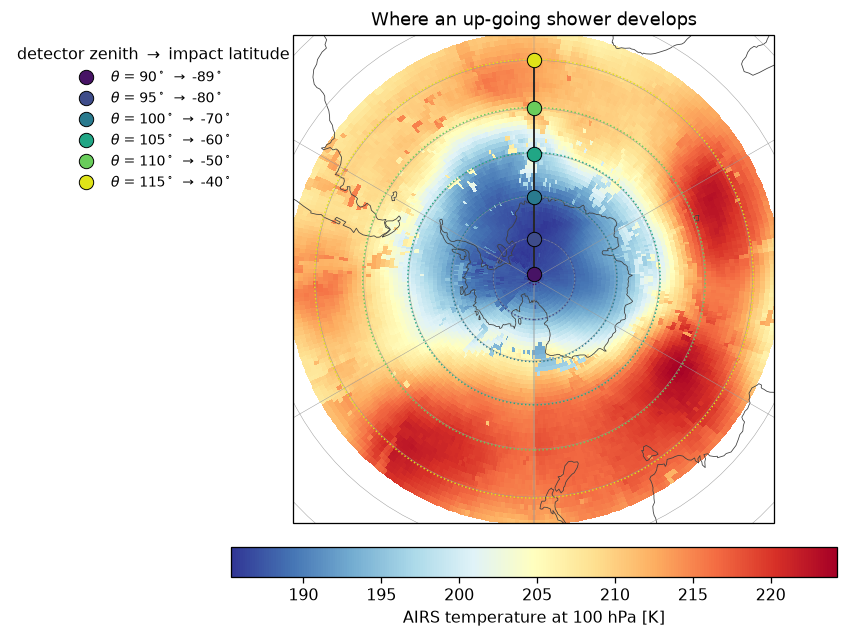

In [19]:
# The impact points along AZIMUTH_DEG, on the air they sample.
shown_T = map_temperature[first_key]

fig = plt.figure(figsize=(8.0, 6.8), dpi=115)
ax = fig.add_subplot(projection=polar)
ax.set_extent([-180, 180, -90, float(lat.max())], ccrs.PlateCarree())
mesh = ax.pcolormesh(np.append(lon, lon[0] + 360), lat,
                     np.concatenate([shown_T, shown_T[:, :1]], axis=1),
                     cmap="RdYlBu_r", shading="auto",
                     transform=ccrs.PlateCarree())
ax.coastlines(lw=0.5, color="0.25")
ax.gridlines(lw=0.3, color="0.6")
plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85,
             label=f"AIRS temperature at {p_hpa[MAP_LEVEL]:.0f} hPa [K]")

circle = np.linspace(-180, 180, 721)
shown = slice(None, None, 2)
ax.plot(impact_lon, impact_lat, "-", color="0.15", lw=1.2, transform=ccrs.Geodetic())
for zenith, latitude, longitude, colour in zip(
        ZENITH_BAND[shown], impact_lat[shown], impact_lon[shown],
        plt.cm.viridis(np.linspace(0.05, 0.95, 6))):
    # the ring of impact points of every azimuth at this zenith
    ax.plot(circle, np.full_like(circle, latitude), ":", color=colour, lw=0.9,
            transform=ccrs.Geodetic())
    ax.plot(longitude, latitude, "o", color=colour, ms=9, mec="k", mew=0.6,
            transform=ccrs.PlateCarree(), zorder=6,
            label=rf"$\theta$ = {zenith:.0f}$^\circ$ $\to$ {latitude:.0f}$^\circ$")
ax.plot(SITE_LON, SITE_LAT, "k*", ms=16, transform=ccrs.PlateCarree(), zorder=5)
# Outside the axes: on the map it covered the quadrant the path runs through.
ax.legend(loc="upper left", bbox_to_anchor=(-0.6, 1.0), fontsize=8.5,
          frameon=False, title="detector zenith $\\to$ impact latitude")
ax.set_title("Where an up-going shower develops", fontsize=11)

def temperature_at(latitude, longitude):
    """The mapped temperature at the grid node nearest an impact point."""
    return shown_T[np.argmin(np.abs(lat - latitude)),
                   np.argmin(np.abs(lon - longitude % 360.0))]


near, far = (temperature_at(impact_lat[k], impact_lon[k]) for k in (0, -1))
print(f"the air at the far end of the path is {far - near:.0f} K warmer "
      f"than the air over the detector")

### The zenith scan, every direction solved

One day of the band: 11 zeniths x 24 azimuths with the settings above, one
solve each, in a single
`solve_batch` call. Three panels: the rate per zenith after integrating over
azimuth, how much air the path crosses, and what the measurement is worth
against climatology. NRLMSISE-21 is azimuth-symmetric at the pole, so one solve
per zenith is its whole ring.

264 AIRS directions and 11 MSIS zeniths in 50 s
AIRS         band-integrated 2.924e-07 /cm^2/s
MSIS21       band-integrated 2.925e-07 /cm^2/s
around the ring at 115 deg the rate varies by 2.02% today


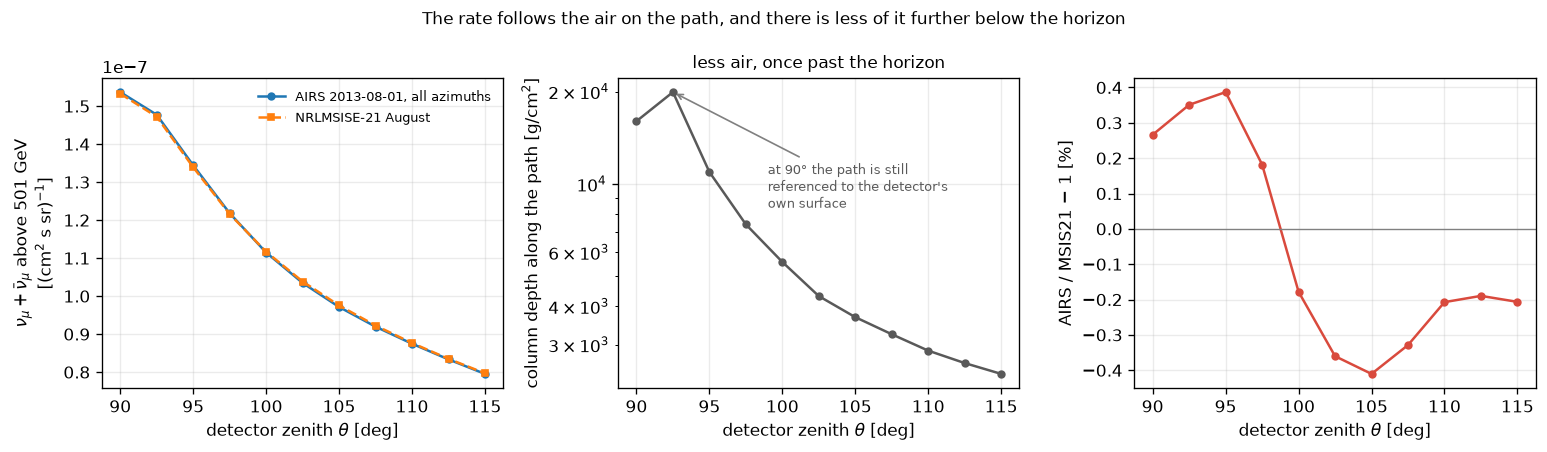

In [20]:
def band_map(tables_by_date):
    """nu_mu + anti-nu_mu rate in every (zenith, azimuth) direction of the up-going
    band, for each day given: one solve per direction and day, nothing averaged
    beforehand.  Returns an array shaped (day, zenith, azimuth)."""
    solution = mceq.solve_batch(conditions=[
        {"zenith_deg": float(z), "azimuth_deg": float(a), "density_model": atm}
        for atm in (detector_atmosphere(t, d) for d, t in tables_by_date.items())
        for z in ZENITH_BAND for a in AZIMUTHS])
    spectra = np.array([sum(solution.get_solution(n, k=k) for n in NU)
                        for k in range(solution.K)])
    return rate(spectra).reshape(len(tables_by_date), ZENITH_BAND.size, AZIMUTHS.size)


def integrate_directions(theta_deg, rate_grid):
    """int dphi int dcos(theta) of the solved rates: per cm^2 s over the band.

    The azimuths are equally spaced, so their integral is 2 pi times their mean:
    a quadrature rule over independent solves, not an average of atmospheres.
    """
    mu = np.cos(np.radians(theta_deg))
    order = np.argsort(mu)
    return 2 * np.pi * np.trapezoid(rate_grid[order].mean(axis=1), mu[order])


start = time.time()
band_today = band_map({START_DATE: table})[0]                 # (zenith, azimuth)
msis_ic = dp.MSIS21IceCubeCentered("SouthPole", "August")
solved = mceq.solve_batch(conditions=[{"zenith_deg": float(z), "density_model": msis_ic}
                                      for z in ZENITH_BAND])
msis_zenith = rate(np.array([sum(solved.get_solution(n, k=k) for n in NU)
                             for k in range(solved.K)]))
print(f"{band_today.size} AIRS directions and {solved.K} MSIS zeniths in "
      f"{time.time() - start:.0f} s")
zenith_rate = band_today.mean(axis=1)      # per steradian, integrated over the ring

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=120)
for row, label, style in ((zenith_rate, f"AIRS {START_DATE}, all azimuths", "-o"),
                          (msis_zenith, "NRLMSISE-21 August", "--s")):
    axes[0].plot(ZENITH_BAND, row, style, ms=4, label=label)
axes[0].set_ylabel(rf"$\nu_\mu+\bar\nu_\mu$ above {edge:.0f} GeV"
                   "\n" r"[(cm$^2$ s sr)$^{-1}$]")
axes[0].legend(fontsize=8, frameon=False)

axes[1].semilogy(ZENITH_BAND, depth, "-o", ms=4, color="0.35")
axes[1].set_ylabel(r"column depth along the path [g/cm$^2$]")
axes[1].set_title("less air, once past the horizon", fontsize=10)
# Below the peak, not above it: at depth[1] * 1.1 the label lands on the title.
axes[1].annotate("at 90° the path is still\nreferenced to the detector's\nown surface",
                 xy=(92.5, depth[1]), xytext=(99, depth[1] * 0.42), fontsize=8,
                 color="0.35", arrowprops=dict(arrowstyle="->", color="0.5"))

axes[2].plot(ZENITH_BAND, 100 * (zenith_rate / msis_zenith - 1), "-o",
             ms=4, color="#d94a3d")
axes[2].axhline(0, color="0.5", lw=0.8)
axes[2].set_ylabel("AIRS / MSIS21 $-$ 1 [%]")
for ax in axes:
    ax.set_xlabel(r"detector zenith $\theta$ [deg]")
    ax.grid(alpha=0.25)
fig.suptitle("The rate follows the air on the path, and there is less of it "
             "further below the horizon", fontsize=10)
fig.tight_layout()

# For a symmetric atmosphere one azimuth is the whole ring.
print(f"{'AIRS':12s} band-integrated {integrate_directions(ZENITH_BAND, band_today):.3e} /cm^2/s")
print(f"{'MSIS21':12s} band-integrated "
      f"{integrate_directions(ZENITH_BAND, msis_zenith[:, None]):.3e} /cm^2/s")
print(f"around the ring at {ZENITH_BAND[-1]:.0f} deg the rate varies by "
      f"{100 * (band_today[-1].max() / band_today[-1].min() - 1):.2f}% today")


### The band on the map

Each direction's rate, drawn at its impact point. The 90° ring lands 1.4° from
the pole and the 115° ring at −40°, so the band covers nearly the same ground as
the vertical rate map, only seen from IceCube through the Earth instead of from
above. At the pole every azimuth is a meridian, so the ring at one zenith is a
circle of latitude and the grid of directions is a grid on the map.

Left, the rate itself: its fall-off outward is the geometry of the middle panel
above, and it hides the weather. Right, each direction against the mean of its
own ring: that is the weather, about 2% around the outer ring on this day,
which is as much as the whole month moves the ring integral below.

Text(0.5, 0.98, 'AIRS 2013-08-01: the up-going band, one solve per direction, drawn at the impact points (11 zeniths x 24 azimuths)')

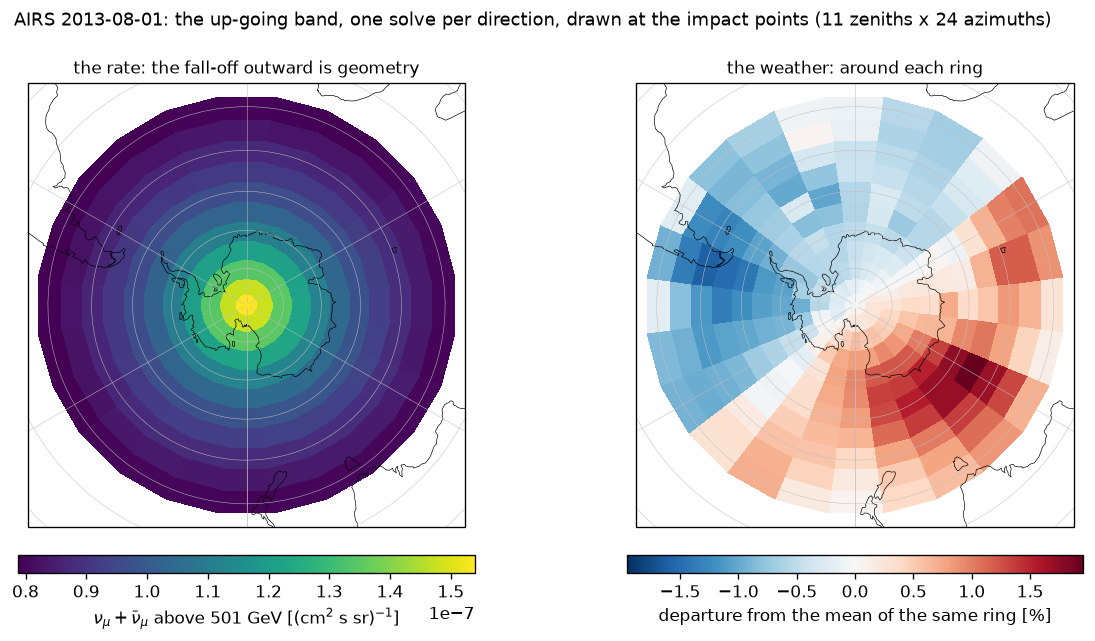

In [21]:
# Where each direction lands: ask the geometry for every (zenith, azimuth).
band_lat = np.empty((ZENITH_BAND.size, AZIMUTHS.size))
band_lon = np.empty_like(band_lat)
for i, zenith in enumerate(ZENITH_BAND):
    for k, azimuth in enumerate(AZIMUTHS):
        ic_atm.set_theta(float(zenith), azimuth_deg=float(azimuth))
        band_lat[i, k] = ic_atm.current_impact_latitude
        band_lon[i, k] = ic_atm.current_impact_longitude % 360.0
# At the pole the impact latitude depends on the zenith alone and the longitude
# on the azimuth alone, which is what lets pcolormesh draw the grid directly.
assert np.allclose(band_lat, band_lat[:, :1])
assert np.abs((band_lon - band_lon[:1] + 180.0) % 360.0 - 180.0).max() < 1e-6
ring_lat = band_lat[:, 0]
ring_order = np.argsort(band_lon[0])           # ascending longitude for the mesh
ring_lon = band_lon[0][ring_order]

# Left, the rate: its fall-off with distance is the geometry of the previous
# figure and hides the weather.  Right, each direction against the mean of its
# own ring: that is the weather.
ring_anomaly = 100 * (band_today / band_today.mean(axis=1, keepdims=True) - 1)

fig = plt.figure(figsize=(12.0, 6.0), dpi=120)
ax = fig.add_subplot(1, 2, 1, projection=polar)
polar_map(ax, band_today[:, ring_order], ring_lat, ring_lon, "viridis",
          rf"$\nu_\mu+\bar\nu_\mu$ above {edge:.0f} GeV [(cm$^2$ s sr)$^{{-1}}$]",
          quant_cmap=False)
ax.plot(SITE_LON, SITE_LAT, "k*", ms=12, transform=ccrs.PlateCarree())
ax.set_title("the rate: the fall-off outward is geometry", fontsize=10)

ax = fig.add_subplot(1, 2, 2, projection=polar)
mesh = polar_map(ax, ring_anomaly[:, ring_order], ring_lat, ring_lon, "RdBu_r",
                 "departure from the mean of the same ring [%]", quant_cmap=False)
mesh.set_clim(-np.abs(ring_anomaly).max(), np.abs(ring_anomaly).max())
ax.plot(SITE_LON, SITE_LAT, "k*", ms=12, transform=ccrs.PlateCarree())
ax.set_title("the weather: around each ring", fontsize=10)
fig.suptitle(f"AIRS {START_DATE}: the up-going band, one solve per direction, drawn at the "
             f"impact points ({ZENITH_BAND.size} zeniths x {AZIMUTHS.size} azimuths)", fontsize=10.5)

### One month, as IceCube would see it

Every direction of the up-going band, on every day of the month: 11 zeniths x
24 azimuths x 31 days with the settings above, each its own solve, `DAYS_PER_CALL` days per call so that
the batched solver stays busy around the 950-step horizontal directions. The
integral over directions is the rate the band would count, per cm² s. The
right-hand map shows how much each direction moved over the month. The ring
integral moves less than most single directions, because the weather is not
the same all round the ring.

  10 days   381 s


  20 days   762 s


  30 days  1129 s


  31 days  1176 s
8184 directions in 1176 s
the ring integral moves 1.43% peak to peak; the median single direction moves 2.06%, the most restless one 4.90%


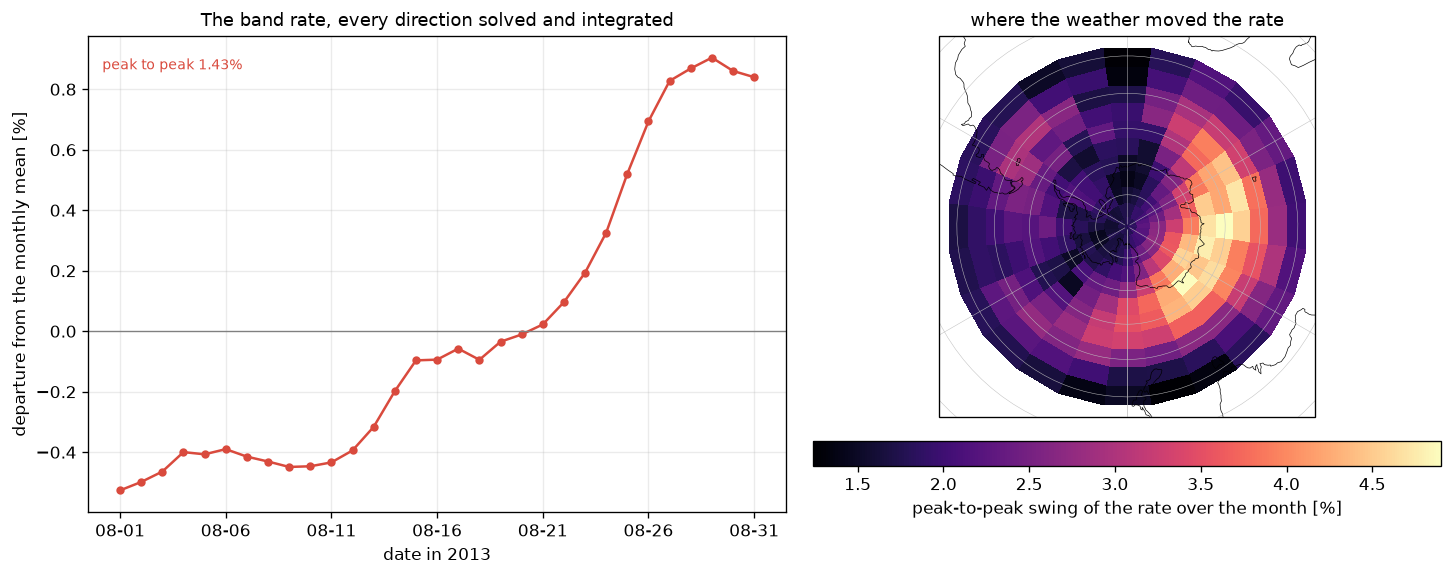

In [22]:
start = time.time()
band = []
for k in range(0, len(month_dates), DAYS_PER_CALL):
    chunk = month_dates[k:k + DAYS_PER_CALL]
    band.append(band_map({d: day_tables[d] for d in chunk}))
    done = k + len(chunk)
    if done % 10 < DAYS_PER_CALL or done == len(month_dates):
        print(f"  {done:2d} days  {time.time() - start:4.0f} s")
band = np.concatenate(band)                                # (day, zenith, azimuth)
band_rate = np.array([integrate_directions(ZENITH_BAND, day) for day in band])
print(f"{band.size} directions in {time.time() - start:.0f} s")

band_anomaly = 100 * (band_rate / band_rate.mean() - 1)
direction_swing = 100 * (band.max(axis=0) / band.min(axis=0) - 1)   # per direction

fig = plt.figure(figsize=(12.5, 4.9), dpi=120)
ax = fig.add_subplot(1, 2, 1)
ax.plot(range(len(month_dates)), band_anomaly, "-o", ms=4, color="#d94a3d")
ax.axhline(0, color="0.5", lw=0.8)
ticks = range(0, len(month_dates), 5)
ax.set_xticks(ticks, [month_dates[k][5:] for k in ticks])
ax.set_ylabel("departure from the monthly mean [%]")
ax.set_xlabel("date in 2013")
ax.grid(alpha=0.25)
ax.set_title("The band rate, every direction solved and integrated", fontsize=11)
ax.text(0.02, 0.93, f"peak to peak {band_anomaly.max() - band_anomaly.min():.2f}%",
        transform=ax.transAxes, ha="left", fontsize=8.5, color="#d94a3d")

ax = fig.add_subplot(1, 2, 2, projection=polar)
polar_map(ax, direction_swing[:, ring_order], ring_lat, ring_lon, "magma",
          "peak-to-peak swing of the rate over the month [%]", quant_cmap=False)
ax.plot(SITE_LON, SITE_LAT, "k*", ms=12, transform=ccrs.PlateCarree())
ax.set_title("where the weather moved the rate", fontsize=11)
fig.tight_layout()

print(f"the ring integral moves {band_anomaly.max() - band_anomaly.min():.2f}% peak to peak; "
      f"the median single direction moves {np.median(direction_swing):.2f}%, "
      f"the most restless one {direction_swing.max():.2f}%")


## Extra: the whole month, animated

The motion is weather. For a smoother map, set `LAT_STRIDE` and `LON_STRIDE` to
1 at the top and re-run.

In [23]:
from matplotlib import animation
from IPython.display import HTML

fig = plt.figure(figsize=(6, 6.4), dpi=110)
ax = fig.add_subplot(projection=polar)
limit = np.percentile(np.abs(anomaly), 99)
mesh = polar_map(ax, anomaly[0], map_lat, map_lon, "RdBu_r",
                 "Rate departure from the monthly mean [%]", quant_cmap=False)
ax.plot(SITE_LON, SITE_LAT, "k*", ms=12, transform=ccrs.PlateCarree())
title = ax.set_title("")


def draw(step):
    closed = np.concatenate([anomaly[step], anomaly[step][:, :1]], axis=1)
    mesh.set_array(closed.ravel())
    title.set_text(month_dates[step])
    return mesh, title


ani = animation.FuncAnimation(fig, draw, frames=len(month_dates), interval=400)
plt.close(fig)
HTML(ani.to_jshtml())